In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X = np.array([
    [170, 65],
    [160, 59],
    [175, 63]
])

In [4]:
X_center = X - np.mean(X, axis=0)
X_center

array([[ 1.66666667,  2.66666667],
       [-8.33333333, -3.33333333],
       [ 6.66666667,  0.66666667]])

In [6]:
C = np.cov(X_center.T)
C

array([[58.33333333, 18.33333333],
       [18.33333333,  9.33333333]])

In [9]:
eig_vals, eig_vecs = np.linalg.eig(C)
eig_vals,eig_vecs

(array([64.43335149,  3.23331518]),
 array([[ 0.94885539, -0.31571101],
        [ 0.31571101,  0.94885539]]))

In [11]:
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]
eig_vals,eig_vecs

(array([64.43335149,  3.23331518]),
 array([[ 0.94885539, -0.31571101],
        [ 0.31571101,  0.94885539]]))

In [12]:
Z = X_center.dot(eig_vecs)
Z

array([[ 2.42332168,  2.00409604],
       [-8.95949831, -0.53192625],
       [ 6.53617664, -1.47216979]])

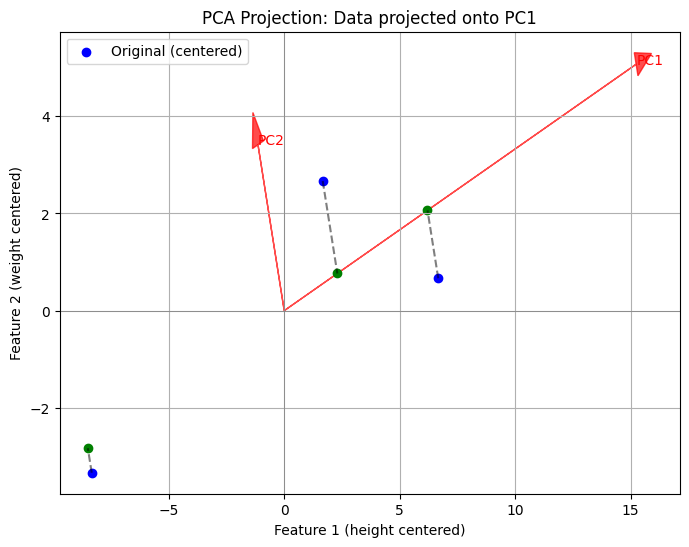

In [14]:
plt.figure(figsize=(8,6))
# วาดจุด original
plt.scatter(X_center[:,0], X_center[:,1], color='blue', label='Original (centered)')

# วาดแกน eigenvectors
origin = np.mean(X_center, axis=0)
for i in range(len(eig_vals)):
    vec = eig_vecs[:, i] * np.sqrt(eig_vals[i]) * 2  # scale ให้เห็นชัด
    plt.arrow(origin[0], origin[1], vec[0], vec[1],
              head_width=0.5, head_length=0.7, color='red', alpha=0.7)
    plt.text(origin[0]+vec[0], origin[1]+vec[1], f"PC{i+1}", color='red')

# วาด projection บน PC1
pc1 = eig_vecs[:,0]  # แกนหลัก
for x in X_center:
    proj_length = np.dot(x, pc1)
    proj_point = proj_length * pc1
    plt.plot([x[0], proj_point[0]], [x[1], proj_point[1]], 'k--', alpha=0.5)
    plt.scatter(proj_point[0], proj_point[1], color='green')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel("Feature 1 (height centered)")
plt.ylabel("Feature 2 (weight centered)")
plt.legend()
plt.title("PCA Projection: Data projected onto PC1")
plt.grid(True)
plt.show()

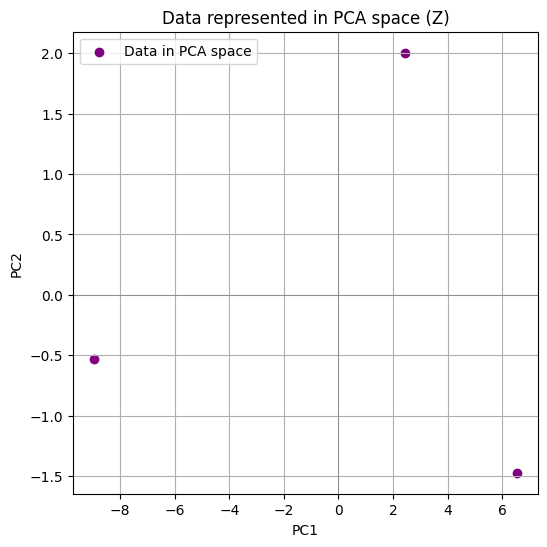

In [15]:
# Plot Z ใน space ใหม่ (PC1, PC2)
plt.figure(figsize=(6,6))
plt.scatter(Z[:,0], Z[:,1], color='purple', label='Data in PCA space')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Data represented in PCA space (Z)")
plt.grid(True)
plt.show()
